In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Excel CSV File/Clean_bank_transactions.csv')
df.head(5)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,01/10/1994,Female,Jamshedpur,17819.05,2/8/16,143207.0,25.0
1,T2,C2142763,04/04/1957,Male,Jhajjar,2270.69,2/8/16,141858.0,27999.0
2,T3,C4417068,26/11/1996,Female,Mumbai,17874.44,2/8/16,142712.0,459.0
3,T4,C5342380,14/09/1973,Female,Mumbai,866503.21,2/8/16,142714.0,2060.0
4,T5,C9031234,24/03/1988,Female,Mumbai,6714.43,2/8/16,181156.0,1762.5


In [3]:
df.shape

(30374, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30374 entries, 0 to 30373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            30374 non-null  object 
 1   CustomerID               30374 non-null  object 
 2   CustomerDOB              30250 non-null  object 
 3   CustGender               30373 non-null  object 
 4   CustLocation             30372 non-null  object 
 5   CustAccountBalance       30340 non-null  float64
 6   TransactionDate          30373 non-null  object 
 7   TransactionTime          30373 non-null  float64
 8   TransactionAmount (INR)  30373 non-null  float64
dtypes: float64(3), object(6)
memory usage: 2.1+ MB


In [5]:
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,3.034000e+04,30373.000000,30373.000000
mean,1.195266e+05,174880.971850,1667.783751
std,6.695741e+05,38799.880135,6621.061966
min,0.000000e+00,10.000000,0.000000
25%,5.457558e+03,152235.000000,150.000000
50%,1.927748e+04,183901.000000,421.000000
75%,6.467677e+04,203552.000000,1150.000000
max,5.099967e+07,235951.000000,455122.000000


In [6]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,124
CustGender,1
CustLocation,2
CustAccountBalance,34
TransactionDate,1
TransactionTime,1
TransactionAmount (INR),1


**Handling missing values**

In [7]:
print(df.duplicated().sum())
print(df['TransactionID'].duplicated().sum())

0
0


In [8]:
df['CustGender']= df['CustGender'].fillna("Unknown")

In [9]:
df['CustGender'].value_counts()

,count
CustGender,
Male,21939
Female,8413
Unknown,22


In [10]:
df['CustLocation'] = df['CustLocation'].fillna("Unknown")

In [11]:
df['CustLocation'].value_counts()

,count
CustLocation,
Delhi,4656
Mumbai,3948
Bangalore,2529
Gurgaon,2124
Noida,1034
...,...
Mahuva,1
Kundli,1
Osmanabad,1


In [12]:
df['CustAccountBalance'] = df['CustAccountBalance'].fillna(df['CustAccountBalance'].median())

In [13]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,124
CustGender,0
CustLocation,0
CustAccountBalance,0
TransactionDate,1
TransactionTime,1
TransactionAmount (INR),1


**Featureing the data**

In [14]:
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'] , dayfirst=True)
print(df['CustomerDOB'].dtype)

datetime64[ns]


In [15]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'] , dayfirst=True)
print(df['TransactionDate'].dtype)

datetime64[ns]


/tmp/ipykernel_3538/3653226917.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TransactionDate'] = pd.to_datetime(df['TransactionDate'] , dayfirst=True)


In [16]:
df['Age'] = (df['TransactionDate'].dt.year - df['CustomerDOB'].dt.year)

In [17]:
df.head(5)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T1,C5841053,1994-10-01,Female,Jamshedpur,17819.05,2016-08-02,143207.0,25.0,22.0
1,T2,C2142763,1957-04-04,Male,Jhajjar,2270.69,2016-08-02,141858.0,27999.0,59.0
2,T3,C4417068,1996-11-26,Female,Mumbai,17874.44,2016-08-02,142712.0,459.0,20.0
3,T4,C5342380,1973-09-14,Female,Mumbai,866503.21,2016-08-02,142714.0,2060.0,43.0
4,T5,C9031234,1988-03-24,Female,Mumbai,6714.43,2016-08-02,181156.0,1762.5,28.0


In [18]:
bins = [0, 25, 35, 45, 55, 65, 200]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age-Groups'] = pd.cut( df['Age'] , bins=bins , labels=labels)

In [19]:
df['Age-Groups'].isnull().sum()

np.int64(2086)

In [20]:
df['Age-Groups'] = df['Age-Groups'].cat.add_categories('Unknown')
df['Age-Groups'] = df['Age-Groups'].fillna('Unknown')

In [21]:
df['Age-Groups'].value_counts()

,count
Age-Groups,
26-35,14230
18-25,7687
36-45,4343
Unknown,2086
46-55,1227
56-65,546
65+,255


In [22]:
df['TransactionYear'] = df['TransactionDate'].dt.year

In [23]:
df['TransactionMonth'] = df['TransactionDate'].dt.month

In [24]:
df['TransactionMonthName'] = df['TransactionDate'].dt.month_name()

In [25]:
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()

In [26]:
df['Day'] = df['TransactionDate'].dt.day

In [27]:
df[['TransactionDate', 'TransactionYear',
   'TransactionMonth', 'TransactionMonthName',
   'DayOfWeek', 'Day']].head()

,TransactionDate,TransactionYear,TransactionMonth,TransactionMonthName,DayOfWeek,Day
0,2016-08-02,2016.0,8.0,August,Tuesday,2.0
1,2016-08-02,2016.0,8.0,August,Tuesday,2.0
2,2016-08-02,2016.0,8.0,August,Tuesday,2.0
3,2016-08-02,2016.0,8.0,August,Tuesday,2.0
4,2016-08-02,2016.0,8.0,August,Tuesday,2.0


In [ ]:
df.to_excel("bank_transactions_processed.xlsx", index=False)

In [ ]:
from google.colab import files

files.download("bank_transactions_processed.xlsx")

In [30]:
df.head(3)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age,Age-Groups,TransactionYear,TransactionMonth,TransactionMonthName,DayOfWeek,Day
0,T1,C5841053,1994-10-01,Female,Jamshedpur,17819.05,2016-08-02,143207.0,25.0,22.0,18-25,2016.0,8.0,August,Tuesday,2.0
1,T2,C2142763,1957-04-04,Male,Jhajjar,2270.69,2016-08-02,141858.0,27999.0,59.0,56-65,2016.0,8.0,August,Tuesday,2.0
2,T3,C4417068,1996-11-26,Female,Mumbai,17874.44,2016-08-02,142712.0,459.0,20.0,18-25,2016.0,8.0,August,Tuesday,2.0


**EDA => Exploratory Data Analysis**

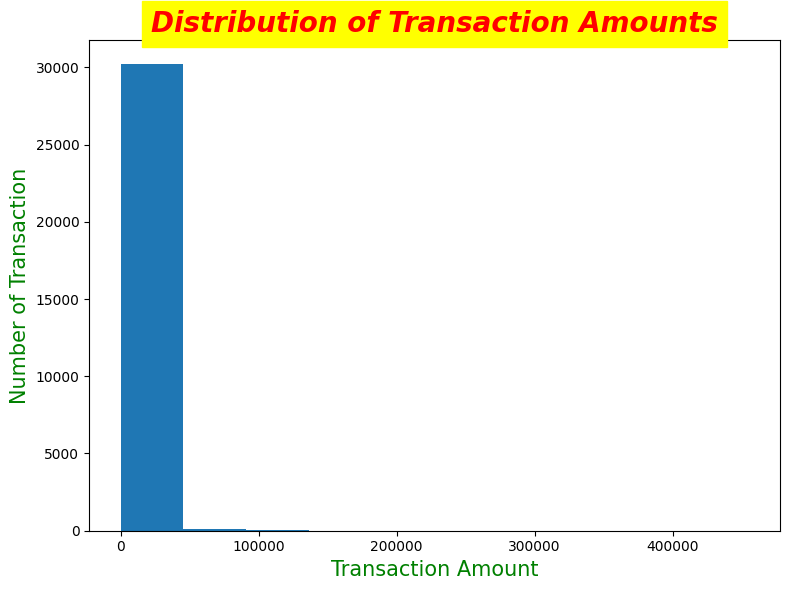

In [29]:
plt.figure(figsize=(8, 6))
plt.hist(df['TransactionAmount (INR)'], bins=10)
plt.title('Distribution of Transaction Amounts' , color='red' , fontstyle='italic' , weight='bold' , backgroundcolor ='yellow' , fontsize = 20)
plt.xlabel('Transaction Amount' , color='green' , fontsize=15)
plt.ylabel('Number of Transaction' , color='green' , fontsize=15)
plt.tight_layout()
plt.show()

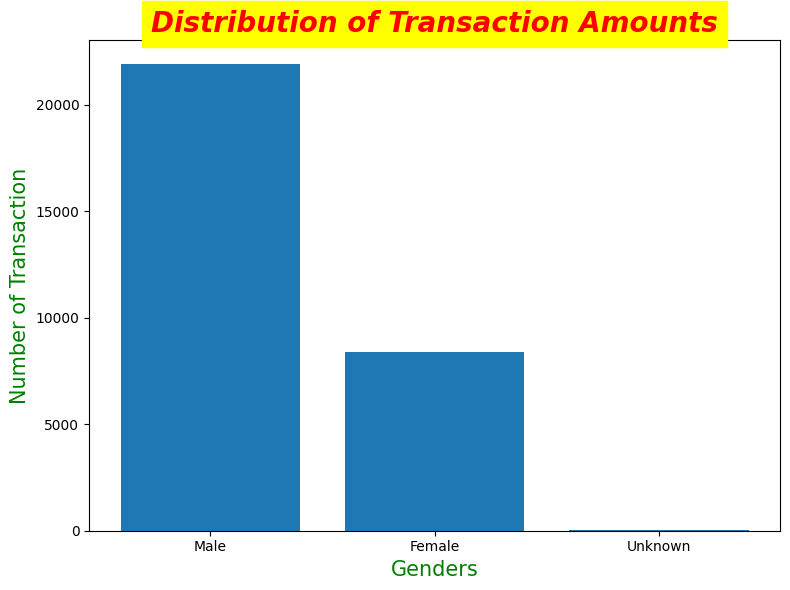

In [31]:
plt.figure(figsize=(8, 6))
plt.bar(df['CustGender'].value_counts().index ,df['CustGender'].value_counts().values)
plt.title('Distribution of Transaction Amounts' , color='red' , fontstyle='italic' , weight='bold' , backgroundcolor ='yellow' , fontsize = 20)
plt.xlabel('Genders' , color='green' , fontsize=15)
plt.ylabel('Number of Transaction' , color='green' , fontsize=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3538/3897022267.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age-Groups')['TransactionAmount (INR)'].mean().sort_index()


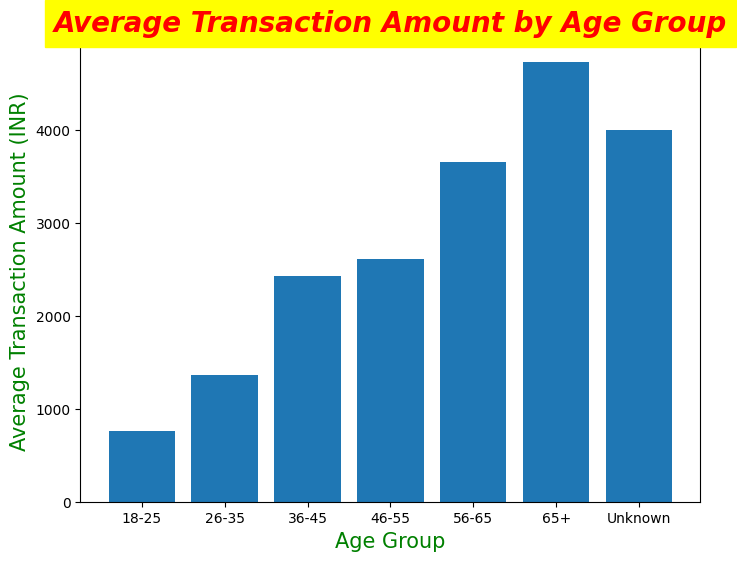

In [32]:
age_transaction = (
    df.groupby('Age-Groups')['TransactionAmount (INR)'].mean().sort_index()
)

plt.figure(figsize=(8, 6))

plt.bar(
    age_transaction.index.astype(str),
    age_transaction.values
)

plt.title('Average Transaction Amount by Age Group' , color='red' , fontstyle='italic' , weight='bold' , backgroundcolor ='yellow' , fontsize = 20)
plt.xlabel('Age Group' , color='green' , fontsize=15)
plt.ylabel('Average Transaction Amount (INR)' , color='green' , fontsize=15)
plt.show()

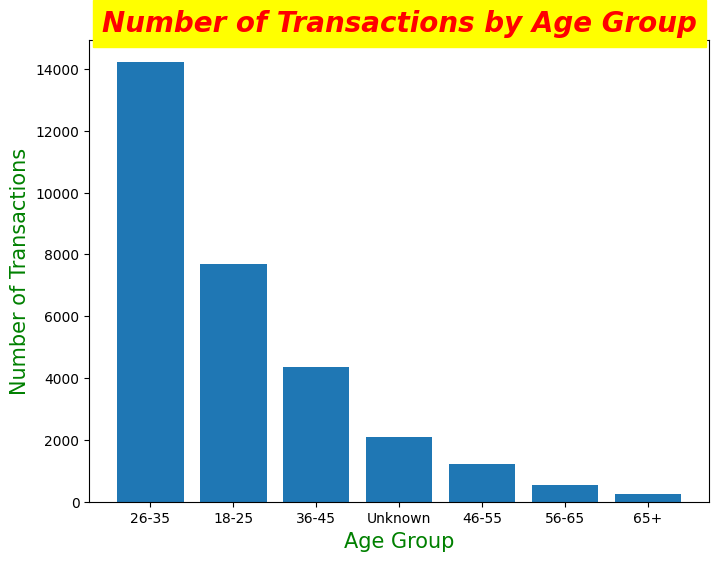

In [33]:
plt.figure(figsize=(8, 6))

plt.bar(df['Age-Groups'].value_counts().index.astype(str) , df['Age-Groups'].value_counts().values)
plt.title('Number of Transactions by Age Group' , color='red' , fontstyle='italic' , weight='bold' , backgroundcolor ='yellow' , fontsize = 20)
plt.xlabel('Age Group' , color='green' , fontsize=15)
plt.ylabel('Number of Transactions' , color='green' , fontsize=15)
plt.show()

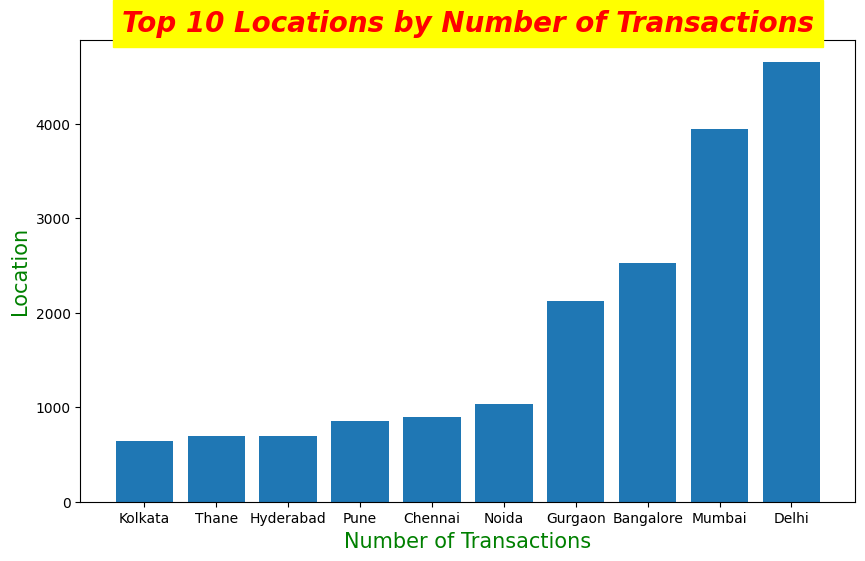

In [42]:
top_locations = df['CustLocation'].value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_locations.index[::-1],
    top_locations.values[::-1] ,
)

plt.title('Top 10 Locations by Number of Transactions' , color='red' , fontstyle='italic' , weight='bold' , backgroundcolor ='yellow' , fontsize = 20)
plt.xlabel('Number of Transactions' , color='green' , fontsize=15)
plt.ylabel('Location' , color='green' , fontsize=15)

plt.show()